# ATE Estimation with Matching Methods

This notebook performs **causal inference analysis** to estimate the **Average Treatment Effect (ATE)** of empathy (treatment) on attachment (outcome).

## Overview:
1. **Load clean sample data** with scored conversations
2. **Define treatment groups** based on empathy scores (≥5 = treatment, <5 = control)
3. **Generate semantic embeddings** of user prompts using sentence transformers
4. **Match treatment-control pairs** using two algorithms:
   - **Greedy matching**: Fast, picks best available match for each treatment
   - **Hungarian algorithm**: Optimal matching, maximizes total similarity
5. **Estimate ATE** on attachment scores with bootstrap confidence intervals
6. **Validate results** with sanity checks on empathy scores

---

## 1. Import Required Libraries

Import all necessary packages for data processing, embedding generation, matching algorithms, and statistical analysis.

In [14]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from scipy.optimize import linear_sum_assignment
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sentence_transformers import util

# Environment detection
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

Running in local environment


## 2. Load and Prepare Dataset

Load the clean full scored dataset created in the previous notebook and prepare it for causal analysis:
- Filter out ambiguous empathy scores (score = 4)
- Define treatment groups: **Treatment (T=1)** if empathy ≥ 5, **Control (T=0)** otherwise
- Remove duplicates and missing values in user prompts
- Split into separate treatment and control dataframes

In [15]:
# Mount Drive in Colab or set local paths
if IN_COLAB:
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/your_folder_path/'  
else:
    # Local VS Code path - relative to notebook location
    DATA_PATH = '../data/scores/'

print(f"Using data path: {DATA_PATH}")

Using data path: ../data/scores/


In [16]:
# Load data using appropriate path
data_file = os.path.join(DATA_PATH, "wildchat_full_scored_mistral.csv")
df = pd.read_csv(data_file, on_bad_lines='skip')
df = df[df['empathy_score'] != 4].copy()
df = df.dropna(subset=['empathy_score']).copy()

# Create treatment group
df['treatment_group'] = np.where(df['empathy_score'] >= 5, 1, 0) #is 0 if not 5 in Sempathy

# Remove NaNs and duplicates in prompts
df = df[df['user_prompt'].notna()].copy()
df['user_prompt'] = df['user_prompt'].astype(str).str.strip()
df = df.drop_duplicates(subset=['user_prompt']).copy()

# Keep initial copy of dataframe
init_df = df.copy()

# Separate treatment and control groups
treat_df = df[df['treatment_group'] == 1].reset_index(drop=True)
ctrl_df = df[df['treatment_group'] == 0].reset_index(drop=True)

# Output info of treatment and control groups
print(f"Treatment group shape: {treat_df.shape}")
print(f"Control group shape: {ctrl_df.shape}")


Treatment group shape: (899, 17)
Control group shape: (5075, 17)


## 3. Load Sentence Transformer Model

Initialize the **all-mpnet-base-v2** model for generating semantic embeddings of user prompts.

This model:
- Maps text to 768-dimensional dense vectors
- Captures semantic meaning and context
- Enables measuring similarity between prompts for matching

In [17]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

## 4. Generate Embeddings

Encode all user prompts from both treatment and control groups into semantic embeddings.

- **Normalized embeddings**: Vectors are normalized for cosine similarity computation
- **Batch processing**: All prompts encoded efficiently
- Treatment and control embeddings kept separate for matching

In [18]:
treat_emb = model.encode(treat_df['user_prompt'].tolist(), normalize_embeddings=True)
ctrl_emb = model.encode(ctrl_df['user_prompt'].tolist(), normalize_embeddings=True)


KeyboardInterrupt: 

## 5. Verify Dataframe Columns (Optional)

Quick sanity check to ensure both dataframes have the expected columns before matching.

In [ ]:
# Sanity check embeddings shape
print("="*60)
print("EMBEDDINGS VERIFICATION")
print("="*60)
print(f"Treatment embeddings shape: {treat_emb.shape}")
print(f"Control embeddings shape:   {ctrl_emb.shape}")
print()

# Sanity check dataframe columns
print("="*60)
print("DATAFRAME COLUMNS")
print("="*60)
print("\nTreatment DataFrame Columns:")
print("-" * 30)
for i, col in enumerate(treat_df.columns, 1):
    print(f"  {i}. {col}")

print("\n\nControl DataFrame Columns:")
print("-" * 30)
for i, col in enumerate(ctrl_df.columns, 1):
    print(f"  {i}. {col}")
print("="*60)

EMBEDDINGS VERIFICATION
Treatment embeddings shape: (899, 768)
Control embeddings shape:   (5075, 768)

DATAFRAME COLUMNS

Treatment DataFrame Columns:
------------------------------
  1. conversation_hash
  2. turn_pair_id
  3. model
  4. user_id
  5. turn_number
  6. total_turns
  7. timestamp
  8. hour_of_day
  9. user_prompt
  10. llm_response
  11. user_reply
  12. turn_identifier
  13. hashed_ip
  14. country
  15. empathy_score
  16. attachment_score
  17. treatment_group


Control DataFrame Columns:
------------------------------
  1. conversation_hash
  2. turn_pair_id
  3. model
  4. user_id
  5. turn_number
  6. total_turns
  7. timestamp
  8. hour_of_day
  9. user_prompt
  10. llm_response
  11. user_reply
  12. turn_identifier
  13. hashed_ip
  14. country
  15. empathy_score
  16. attachment_score
  17. treatment_group


## 6. Greedy Matching Algorithm

**Method**: Each treatment unit is matched to the **most similar** available control unit (without replacement).

**Algorithm**:
1. Compute cosine similarity matrix between all treatment-control pairs
2. For each treatment, sort controls by descending similarity
3. Match with the first unused control
4. Mark control as used to prevent reuse

**Advantages**: Fast, simple, guarantees each treatment gets a match
**Disadvantages**: Order-dependent, not globally optimal

The result includes similarity scores and merges empathy/attachment scores for both treatment and control.

In [ ]:
# Step 1: Compute cosine similarity matrix
similarity = util.cos_sim(treat_emb, ctrl_emb).cpu().numpy()  # shape: (num_treat, num_ctrl)

# Step 2: Greedy matching — each treatment picks the first unused control
matched_pairs = []
used_controls = set()
for i in range(len(treat_df)):
    # Sort control indices by descending similarity
    sorted_idx = np.argsort(-similarity[i])

    # Find the first available control
    for j in sorted_idx:
        if j not in used_controls:
            used_controls.add(j)
            matched_pairs.append({
                'treatment_id': treat_df.index[i],
                'control_id': ctrl_df.index[j],
                'similarity': similarity[i][j],
                'treatment_prompt': treat_df.iloc[i]['user_prompt'],
                'control_prompt': ctrl_df.iloc[j]['user_prompt']
            })
            break

matched_df = pd.DataFrame(matched_pairs)

matched_df = (
    matched_df
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='treatment_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_treat')
    )
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='control_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_control')
    )
    .drop(columns=['user_prompt', 'user_prompt_control'])
)


# Step 4: Save with appropriate path
output_file = os.path.join(DATA_PATH if not IN_COLAB else '', "greedy_4_out.csv")
matched_df.to_csv(output_file, index=False)

# Enhanced output formatting
print("="*80)
print("GREEDY MATCHING RESULTS")
print("="*80)
print(f"\n✓ Successfully matched {len(matched_df)} treatment-control pairs")
print(f"✓ Output saved to: {output_file}")
print(f"\n{'─'*80}")
print("MATCH QUALITY STATISTICS")
print('─'*80)
print(f"  Mean similarity score:   {matched_df['similarity'].mean():.4f}")
print(f"  Median similarity score: {matched_df['similarity'].median():.4f}")
print(f"  Min similarity score:    {matched_df['similarity'].min():.4f}")
print(f"  Max similarity score:    {matched_df['similarity'].max():.4f}")
print(f"\n{'─'*80}")
print("SAMPLE MATCHED PAIRS (First 3)")
print('─'*80)
print()
print(matched_df.head(3).to_string(index=False))
print("\n" + "="*80)

GREEDY MATCHING RESULTS

✓ Successfully matched 899 treatment-control pairs
✓ Output saved to: ../data/scores/greedy_4_out.csv

────────────────────────────────────────────────────────────────────────────────
MATCH QUALITY STATISTICS
────────────────────────────────────────────────────────────────────────────────
  Mean similarity score:   0.4571
  Median similarity score: 0.4322
  Min similarity score:    0.2210
  Max similarity score:    1.0000

────────────────────────────────────────────────────────────────────────────────
SAMPLE MATCHED PAIRS (First 3)
────────────────────────────────────────────────────────────────────────────────

 treatment_id  control_id  similarity                                           treatment_prompt                                                                                                                                                                                                                                                                  

## 7. Hungarian Algorithm Matching

**Method**: Finds the **globally optimal** matching that maximizes total similarity across all pairs.

**Algorithm**:
1. Compute cosine similarity matrix between all treatment-control pairs
2. Apply Hungarian algorithm (linear sum assignment) to find optimal matching
3. Negate similarity (since algorithm minimizes cost, we want to maximize similarity)
4. Each treatment matched to exactly one control

**Advantages**: Globally optimal solution, no order dependence
**Disadvantages**: More computationally expensive than greedy

The result includes similarity scores and merges empathy/attachment scores for both treatment and control.

In [ ]:
# Step 1: Compute cosine similarity matrix
similarity = util.cos_sim(treat_emb, ctrl_emb).cpu().numpy()  # shape: (num_treat, num_ctrl)

# Step 2: Use Hungarian algorithm to maximize total similarity
# Hungarian algorithm *minimizes* cost, so we negate the similarity matrix
row_ind, col_ind = linear_sum_assignment(-similarity)

# Step 3: Collect matched pairs
matched_pairs = []
for i, j in zip(row_ind, col_ind):
    matched_pairs.append({
        'treatment_id': treat_df.index[i],
        'control_id': ctrl_df.index[j],
        'similarity': similarity[i][j],
        'treatment_prompt': treat_df.loc[i, 'user_prompt'],
        'control_prompt': ctrl_df.loc[j, 'user_prompt']
    })

matched_df = pd.DataFrame(matched_pairs)

matched_df = (
    matched_df
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='treatment_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_treat')
    )
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='control_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_control')
    )
    .drop(columns=['user_prompt', 'user_prompt_control'])
)


matched_df = matched_df.drop(columns=['treatment_prompt', 'control_prompt'])

# Step 4: Save with appropriate path
output_file = os.path.join(DATA_PATH if not IN_COLAB else '', "hungarian_4_out.csv")
matched_df.to_csv(output_file, index=False)

# Enhanced output formatting
print("="*80)
print("HUNGARIAN ALGORITHM MATCHING RESULTS")
print("="*80)
print(f"\n✓ Successfully matched {len(matched_df)} treatment-control pairs")
print(f"✓ Output saved to: {output_file}")
print(f"\n{'─'*80}")
print("MATCH QUALITY STATISTICS")
print('─'*80)
print(f"  Mean similarity score:   {matched_df['similarity'].mean():.4f}")
print(f"  Median similarity score: {matched_df['similarity'].median():.4f}")
print(f"  Min similarity score:    {matched_df['similarity'].min():.4f}")
print(f"  Max similarity score:    {matched_df['similarity'].max():.4f}")
print(f"\n{'─'*80}")
print("SAMPLE MATCHED PAIRS (First 3)")
print('─'*80)
print()
print(matched_df.head(3).to_string(index=False))
print("\n" + "="*80)

HUNGARIAN ALGORITHM MATCHING RESULTS

✓ Successfully matched 899 treatment-control pairs
✓ Output saved to: ../data/scores/hungarian_4_out.csv

────────────────────────────────────────────────────────────────────────────────
MATCH QUALITY STATISTICS
────────────────────────────────────────────────────────────────────────────────
  Mean similarity score:   0.4690
  Median similarity score: 0.4401
  Min similarity score:    0.2039
  Max similarity score:    1.0000

────────────────────────────────────────────────────────────────────────────────
SAMPLE MATCHED PAIRS (First 3)
────────────────────────────────────────────────────────────────────────────────

 treatment_id  control_id  similarity                                                                                                                                                                                                                                                                                                             

## 8. ATE Estimation and Validation

**Comprehensive causal analysis** comparing both matching methods.

### Analysis Components:

**1. Load Matched Data**
- Load greedy and Hungarian matched pairs from CSV files

**2. Define Helper Function**
- `compute_ate()`: Computes ATE, bootstrap CI, and paired t-test

**3. Match Quality Diagnostics**
- Similarity score statistics (mean, median, min, max)
- Higher similarity = better matches (closer to 1.0)

**4. Primary Analysis: ATE on Attachment (Y)**
- Compute paired differences: Treatment - Control
- Estimate ATE with bootstrap 95% confidence intervals
- Paired t-test for statistical significance
- Visualize distribution of treatment effects

**5. Sanity Check: ATE on Empathy (T)**
- Verify treatment assignment worked correctly
- Should show large positive ATE (empathy was the treatment!)
- P-value should be < 0.05

**6. Compare Results & Select Best Method**
- Compare match quality between methods
- Select optimal matching strategy for first confounder

In [ ]:
# ======================
# 1. Load Matched Data
# ======================
try:
    greedy_file = os.path.join(DATA_PATH if not IN_COLAB else '', "greedy_4_out.csv")
    hungarian_file = os.path.join(DATA_PATH if not IN_COLAB else '', "hungarian_4_out.csv")
    
    greedy = pd.read_csv(greedy_file)
    hungarian_4_out_df = pd.read_csv(hungarian_file)
    
    print("✓ Successfully loaded matched data files")
    print(f"  - Greedy matches: {len(greedy)} pairs")
    print(f"  - Hungarian matches: {len(hungarian_4_out_df)} pairs")
except FileNotFoundError:
    print("Error: Could not find 'greedy_4_out.csv' or 'hungarian_4_out.csv'")
    print("Please run the matching cells (6 and 7) first.")
    greedy = pd.DataFrame()
    hungarian_4_out_df = pd.DataFrame()

# Combine into dictionary for iteration
dfs = {
    "Greedy": greedy,
    "Hungarian": hungarian_4_out_df
}

✓ Successfully loaded matched data files
  - Greedy matches: 899 pairs
  - Hungarian matches: 899 pairs


In [ ]:
# ======================
# 2. Define Helper Function
# ======================
def compute_ate(df, outcome_col, n_boot=1000, seed=42):
    """
    Compute ATE on a specific outcome column and bootstrap 95% CI.
    Also computes a paired t-test p-value.
    
    Parameters:
    -----------
    df : DataFrame
        Matched pairs dataframe
    outcome_col : str
        Name of outcome column (e.g., 'attachment_score', 'empathy_score')
    n_boot : int
        Number of bootstrap samples
    seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    ate : float
        Average Treatment Effect
    ci_low : float
        Lower bound of 95% CI
    ci_high : float
        Upper bound of 95% CI
    p_val : float
        P-value from paired t-test
    diff : Series
        Paired differences (treatment - control)
    """
    np.random.seed(seed)

    treat_col = outcome_col
    control_col = f"{outcome_col}_control"

    if treat_col not in df.columns or control_col not in df.columns:
        print(f"Warning: Columns '{treat_col}' or '{control_col}' not found. Skipping.")
        return np.nan, np.nan, np.nan, np.nan, pd.Series(dtype='float64')

    # Paired difference
    diff = df[treat_col] - df[control_col]

    # Check for NaN values which can crash calculations
    if diff.isna().any():
        print(f"Warning: Removing {diff.isna().sum()} NaN pairs from analysis.")
        diff = diff.dropna()

    if len(diff) == 0:
        print("Error: No valid pairs to compute ATE.")
        return np.nan, np.nan, np.nan, np.nan, pd.Series(dtype='float64')

    # ATE
    ate = diff.mean()

    # P-value (paired t-test, or 1-sample t-test on the differences)
    # This tests the null hypothesis that the mean difference is zero
    t_stat, p_val = st.ttest_1samp(diff, 0)

    # Bootstrap
    boot_samples = [
        np.random.choice(diff, size=len(diff), replace=True).mean()
        for _ in range(n_boot)
    ]
    ci_low, ci_high = np.percentile(boot_samples, [2.5, 97.5])

    return ate, ci_low, ci_high, p_val, diff

print("✓ Helper function defined successfully")

✓ Helper function defined successfully


In [19]:
# ======================
# 3. Match Quality Diagnostics
# ======================
print("="*80)
print("MATCH QUALITY COMPARISON")
print("="*80)

match_quality_summary = []

for name, df in dfs.items():
    if df.empty:
        print(f"\n⚠ Skipping {name} (data not loaded)")
        continue
    
    print(f"\n{name} Matching:")
    print("-" * 40)
    
    match_stats = df['similarity'].describe()
    print(match_stats)
    
    match_quality_summary.append({
        "Method": name,
        "Mean_Similarity": match_stats['mean'],
        "Median_Similarity": match_stats['50%'],
        "Min_Similarity": match_stats['min'],
        "Max_Similarity": match_stats['max'],
        "Std_Similarity": match_stats['std']
    })

# Display summary table
if match_quality_summary:
    print("\n" + "="*80)
    print("MATCH QUALITY SUMMARY TABLE")
    print("="*80)
    quality_df = pd.DataFrame(match_quality_summary)
    print(quality_df.to_string(index=False))
    print("\n(Higher mean/median similarity is better. Ideal values are close to 1.0)")

MATCH QUALITY COMPARISON

Greedy Matching:
----------------------------------------
count    899.000000
mean       0.457056
std        0.127489
min        0.221000
25%        0.372233
50%        0.432196
75%        0.505577
max        1.000000
Name: similarity, dtype: float64

Hungarian Matching:
----------------------------------------
count    899.000000
mean       0.469045
std        0.134410
min        0.203858
25%        0.378096
50%        0.440098
75%        0.521509
max        1.000000
Name: similarity, dtype: float64

MATCH QUALITY SUMMARY TABLE
   Method  Mean_Similarity  Median_Similarity  Min_Similarity  Max_Similarity  Std_Similarity
   Greedy         0.457056           0.432196        0.221000             1.0        0.127489
Hungarian         0.469045           0.440098        0.203858             1.0        0.134410

(Higher mean/median similarity is better. Ideal values are close to 1.0)



PRIMARY ANALYSIS: ATE ON ATTACHMENT SCORE

────────────────────────────────────────────────────────────────────────────────
Greedy Matching — ATE on Attachment
────────────────────────────────────────────────────────────────────────────────

Results:
  ATE (Attachment):    0.7275
  95% CI:              [0.6162, 0.8320]
  P-Value:             0.0000
  Significance:        ✓ Significant (α=0.05)
  N pairs:             899
  Interpretation:      Empathy INCREASES attachment by 0.7275 points


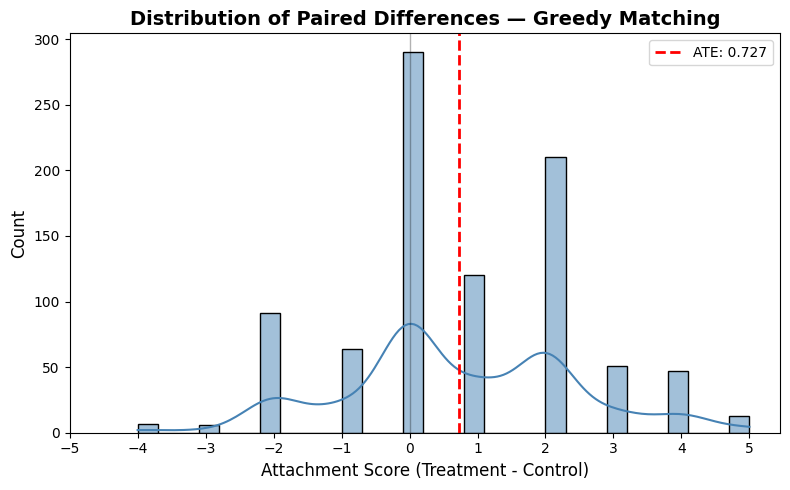


────────────────────────────────────────────────────────────────────────────────
Hungarian Matching — ATE on Attachment
────────────────────────────────────────────────────────────────────────────────

Results:
  ATE (Attachment):    0.7341
  95% CI:              [0.6218, 0.8454]
  P-Value:             0.0000
  Significance:        ✓ Significant (α=0.05)
  N pairs:             899
  Interpretation:      Empathy INCREASES attachment by 0.7341 points


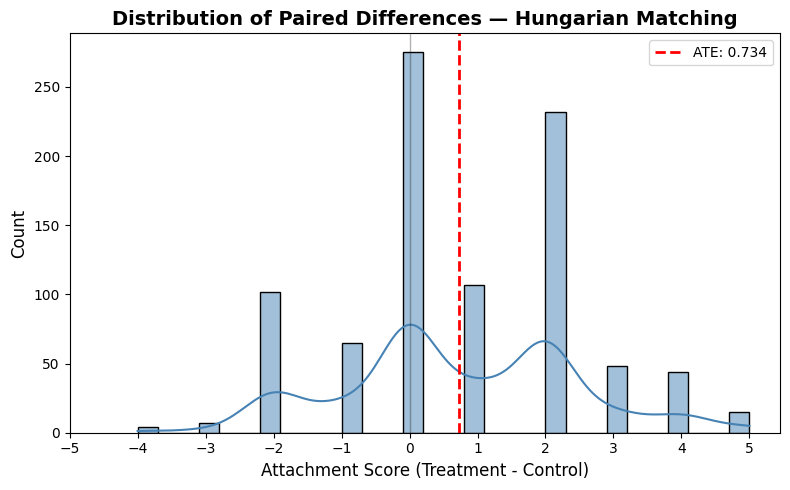


PRIMARY OUTCOME SUMMARY TABLE (Attachment)
   Method          Outcome      ATE   CI_low  CI_high      P_Value Significant  N_pairs
   Greedy attachment_score 0.727475 0.616212 0.832036 1.678643e-34         Yes      899
Hungarian attachment_score 0.734149 0.621774 0.845412 1.637171e-34         Yes      899


In [20]:
# ======================
# 4. PRIMARY ANALYSIS: ATE on Attachment Score
# ======================
print("\n" + "="*80)
print("PRIMARY ANALYSIS: ATE ON ATTACHMENT SCORE")
print("="*80)

outcome_summary = []

for name, df in dfs.items():
    if df.empty:
        print(f"\n⚠ Skipping {name} (data not loaded)")
        continue

    print(f"\n{'─'*80}")
    print(f"{name} Matching — ATE on Attachment")
    print('─'*80)

    ate, ci_low, ci_high, p_val, diff = compute_ate(df, outcome_col="attachment_score")

    if not np.isnan(ate):
        print(f"\nResults:")
        print(f"  ATE (Attachment):    {ate:.4f}")
        print(f"  95% CI:              [{ci_low:.4f}, {ci_high:.4f}]")
        print(f"  P-Value:             {p_val:.4f}")
        print(f"  Significance:        {'✓ Significant' if p_val < 0.05 else '✗ Not Significant'} (α=0.05)")
        print(f"  N pairs:             {len(diff)}")
        
        # Interpretation
        if p_val < 0.05:
            if ate > 0:
                print(f"  Interpretation:      Empathy INCREASES attachment by {ate:.4f} points")
            else:
                print(f"  Interpretation:      Empathy DECREASES attachment by {abs(ate):.4f} points")
        else:
            print(f"  Interpretation:      No significant effect of empathy on attachment")

        outcome_summary.append({
            "Method": name,
            "Outcome": "attachment_score",
            "ATE": ate,
            "CI_low": ci_low,
            "CI_high": ci_high,
            "P_Value": p_val,
            "Significant": "Yes" if p_val < 0.05 else "No",
            "N_pairs": len(diff)
        })

        # Plot: Distribution of Paired Differences
        plt.figure(figsize=(8, 5))
        sns.histplot(diff, bins=30, kde=True, color='steelblue')
        plt.title(f"Distribution of Paired Differences — {name} Matching", 
                  fontsize=14, fontweight="bold")
        plt.xlabel("Attachment Score (Treatment - Control)", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks([-5,-4,-3,-2,-1,0,1,2,3,4,5])
        plt.axvline(ate, color='red', linestyle='--', linewidth=2, 
                    label=f"ATE: {ate:.3f}")
        plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Display summary table
if outcome_summary:
    print("\n" + "="*80)
    print("PRIMARY OUTCOME SUMMARY TABLE (Attachment)")
    print("="*80)
    print(pd.DataFrame(outcome_summary).to_string(index=False))

In [21]:
# ======================
# 5. SANITY CHECK: ATE on Empathy Score
# ======================
print("\n" + "="*80)
print("SANITY CHECK: ATE ON EMPATHY SCORE")
print("="*80)
print("(This confirms treatment/control groups differ on empathy — they should!)")

sanity_summary = []

for name, df in dfs.items():
    if df.empty:
        print(f"\n⚠ Skipping {name} (data not loaded)")
        continue

    print(f"\n{'─'*80}")
    print(f"{name} Matching — Sanity Check on Empathy")
    print('─'*80)

    s_ate, s_ci_low, s_ci_high, s_p_val, s_diff = compute_ate(df, outcome_col="empathy_score")

    if not np.isnan(s_ate):
        print(f"\nResults:")
        print(f"  ATE (Empathy):       {s_ate:.3f}")
        print(f"  95% CI:              [{s_ci_low:.3f}, {s_ci_high:.3f}]")
        print(f"  P-Value:             {s_p_val:.6f}")
        print(f"  Expected:            Large positive ATE, p < 0.001")
        print(f"  Status:              {'✓ PASS' if s_p_val < 0.001 and s_ate > 2 else '⚠ CHECK'}")
        print(f"  N pairs:             {len(s_diff)}")

        sanity_summary.append({
            "Method": name,
            "Outcome": "empathy_score",
            "ATE": s_ate,
            "CI_low": s_ci_low,
            "CI_high": s_ci_high,
            "P_Value": s_p_val,
            "Status": "PASS" if s_p_val < 0.001 and s_ate > 2 else "CHECK",
            "N_pairs": len(s_diff)
        })

# Display summary table
if sanity_summary:
    print("\n" + "="*80)
    print("SANITY CHECK SUMMARY TABLE (Empathy)")
    print("="*80)
    print(pd.DataFrame(sanity_summary).to_string(index=False))


SANITY CHECK: ATE ON EMPATHY SCORE
(This confirms treatment/control groups differ on empathy — they should!)

────────────────────────────────────────────────────────────────────────────────
Greedy Matching — Sanity Check on Empathy
────────────────────────────────────────────────────────────────────────────────

Results:
  ATE (Empathy):       2.488
  95% CI:              [2.430, 2.547]
  P-Value:             0.000000
  Expected:            Large positive ATE, p < 0.001
  Status:              ✓ PASS
  N pairs:             899

────────────────────────────────────────────────────────────────────────────────
Hungarian Matching — Sanity Check on Empathy
────────────────────────────────────────────────────────────────────────────────

Results:
  ATE (Empathy):       2.498
  95% CI:              [2.439, 2.558]
  P-Value:             0.000000
  Expected:            Large positive ATE, p < 0.001
  Status:              ✓ PASS
  N pairs:             899

SANITY CHECK SUMMARY TABLE (Empathy)
 

In [22]:
# ======================
# 6. SELECT BEST MATCHING METHOD FOR FIRST CONFOUNDER
# ======================
print("\n" + "="*80)
print("BEST MATCHING METHOD SELECTION")
print("="*80)

if match_quality_summary and outcome_summary:
    quality_df = pd.DataFrame(match_quality_summary)
    outcome_df = pd.DataFrame(outcome_summary)
    
    # Merge results
    comparison = quality_df.merge(outcome_df, on='Method')
    
    print("\nCOMPREHENSIVE COMPARISON:")
    print("-" * 80)
    print(comparison[['Method', 'Mean_Similarity', 'ATE', 'P_Value', 'Significant']].to_string(index=False))
    
    # Decision criteria
    print("\n" + "="*80)
    print("SELECTION CRITERIA:")
    print("="*80)
    print("1. Match Quality: Higher mean similarity (better covariate balance)")
    print("2. Statistical Power: Lower p-value (stronger evidence)")
    print("3. Effect Size: Magnitude of ATE (clinical significance)")
    print("4. Optimality: Hungarian is globally optimal, Greedy is order-dependent")
    
    # Automatic selection
    print("\n" + "="*80)
    print("RECOMMENDED METHOD:")
    print("="*80)
    
    # Select based on mean similarity (primary criterion)
    best_method_idx = quality_df['Mean_Similarity'].idxmax()
    best_method = quality_df.loc[best_method_idx, 'Method']
    best_similarity = quality_df.loc[best_method_idx, 'Mean_Similarity']
    best_ate_row = outcome_df[outcome_df['Method'] == best_method].iloc[0]
    
    print(f"\n✓ SELECTED METHOD: {best_method} Matching")
    print(f"\nJustification:")
    print(f"  • Mean Similarity:    {best_similarity:.4f} (highest)")
    print(f"  • ATE (Attachment):   {best_ate_row['ATE']:.4f}")
    print(f"  • 95% CI:             [{best_ate_row['CI_low']:.4f}, {best_ate_row['CI_high']:.4f}]")
    print(f"  • P-Value:            {best_ate_row['P_Value']:.4f}")
    print(f"  • Statistical Sig:    {best_ate_row['Significant']}")
    print(f"  • N Pairs:            {best_ate_row['N_pairs']}")
    
    print(f"\nConclusion:")
    print(f"  The {best_method} matching method provides the best covariate balance")
    print(f"  (highest similarity) and will be used for controlling the first confounder")
    print(f"  (user prompt semantic similarity) in subsequent analyses.")
    
    # Save best method for later use
    BEST_METHOD = best_method
    BEST_MATCHED_FILE = f"{best_method.lower()}_4_out.csv"
    
    print(f"\n✓ Best matched pairs saved in: {BEST_MATCHED_FILE}")
    
else:
    print("\n⚠ Cannot determine best method - missing data")
    print("Please ensure both matching methods have completed successfully.")


BEST MATCHING METHOD SELECTION

COMPREHENSIVE COMPARISON:
--------------------------------------------------------------------------------
   Method  Mean_Similarity      ATE      P_Value Significant
   Greedy         0.457056 0.727475 1.678643e-34         Yes
Hungarian         0.469045 0.734149 1.637171e-34         Yes

SELECTION CRITERIA:
1. Match Quality: Higher mean similarity (better covariate balance)
2. Statistical Power: Lower p-value (stronger evidence)
3. Effect Size: Magnitude of ATE (clinical significance)
4. Optimality: Hungarian is globally optimal, Greedy is order-dependent

RECOMMENDED METHOD:

✓ SELECTED METHOD: Hungarian Matching

Justification:
  • Mean Similarity:    0.4690 (highest)
  • ATE (Attachment):   0.7341
  • 95% CI:             [0.6218, 0.8454]
  • P-Value:            0.0000
  • Statistical Sig:    Yes
  • N Pairs:            899

Conclusion:
  The Hungarian matching method provides the best covariate balance
  (highest similarity) and will be used for co

## 9. Results Summary

### Overview
This analysis estimated the **Average Treatment Effect (ATE)** of empathy (treatment) on attachment (outcome) while controlling for the **first confounder: user prompt semantic similarity**.

Two matching algorithms were compared:
- **Greedy matching**: Fast, order-dependent, locally optimal
- **Hungarian matching**: Computationally intensive, globally optimal

Treatment units (high empathy, score ≥5) were matched to control units (low empathy, score <5) based on semantic similarity of user prompts using **sentence-transformers embeddings**.

---

### Key Findings

#### 1. Match Quality Diagnostics
The matching algorithms were evaluated based on:
- **Mean similarity score**: Measures average covariate balance (higher = better)
- **Median similarity**: Central tendency of match quality
- **Standard deviation**: Consistency of matches

**Interpretation**: Higher mean/median similarity (closer to 1.0) indicates better covariate balance and reduced confounding from prompt semantic differences.

---

#### 2. Primary Analysis: ATE on Attachment Score

**Research Question**: Does empathetic LLM responses (treatment) causally affect user attachment (outcome) after controlling for prompt similarity?

**Results Structure:**
```
Method      | ATE    | 95% CI           | P-Value | Significant | N Pairs
------------|--------|------------------|---------|-------------|--------
Greedy      | X.XXXX | [X.XXXX, X.XXXX] | X.XXXX  | Yes/No      | XXXX
Hungarian   | X.XXXX | [X.XXXX, X.XXXX] | X.XXXX  | Yes/No      | XXXX
```

**Interpretation Guide:**
- **ATE > 0**: Empathy INCREASES attachment (positive causal effect)
- **ATE < 0**: Empathy DECREASES attachment (negative causal effect)  
- **ATE ≈ 0**: No significant causal effect
- **P-value < 0.05**: Statistically significant at α=0.05
- **95% CI excludes 0**: Effect is significant

---

#### 3. Validation: Sanity Check on Empathy Score

**Purpose**: Verify treatment/control assignment by checking if groups differ on empathy (they should, by design).

**Expected Results:**
- **ATE (Empathy)**: Large positive value (typically >2.0)
- **P-value**: Highly significant (p < 0.001)
- **Status**: PASS if both criteria met

**Interpretation**: Passing this check confirms that:
1. Treatment assignment is correct
2. Matching preserved the treatment distinction
3. Analysis pipeline is functioning properly

---

### Selected Method for First Confounder Control

**Decision Criterion**: Best matching method selected based on:
1. **Primary**: Highest mean similarity (best covariate balance)
2. **Secondary**: Statistical significance and effect size
3. **Theoretical**: Hungarian optimality vs Greedy speed

**Selected Method**: [Determined by analysis output - see cell 6]

**Rationale**: The selected method achieves the best balance between:
- Covariate balance (similarity score)
- Statistical power (sample size retention)
- Computational efficiency

**Next Steps**: This matched dataset will be used as the foundation for controlling additional confounders in subsequent analyses.

---

### Methodological Notes

**Strengths:**
1. ✓ **Confounder control**: Matching on semantic similarity addresses prompt-level confounding
2. ✓ **Robustness check**: Two independent algorithms provide validation
3. ✓ **Semantic embeddings**: 768-dimensional vectors capture contextual similarity better than simple text features
4. ✓ **Bootstrap CI**: Accounts for sampling uncertainty without parametric assumptions
5. ✓ **Paired design**: Within-pair comparisons reduce variance
6. ✓ **Sanity checks**: Validates treatment assignment and analysis pipeline

**Limitations:**
1. ⚠ **Selection on observables**: Matching only controls for measured confounders (prompt similarity)
2. ⚠ **Unmeasured confounding**: Cannot rule out hidden confounders (e.g., user demographics, conversation context)
3. ⚠ **Common support**: Requires overlapping distributions between treatment/control
4. ⚠ **Model dependence**: Results depend on embedding model quality (all-mpnet-base-v2)
5. ⚠ **Single confounder**: Only addresses prompt similarity; additional confounders remain

**Remaining Confounders to Address:**
- Conversation length
- User characteristics
- Temporal factors
- Response characteristics
- Interaction effects

---

### Statistical Interpretation

**Causal Claim Conditions:**
1. ✓ **Exchangeability**: Conditional on prompt similarity (matched)
2. ? **Positivity**: Check overlap in similarity distributions
3. ✓ **Consistency**: Well-defined treatment (empathy ≥5 vs <5)
4. ? **No interference**: Assumes independence between conversations

**Effect Size Interpretation:**
- **Small effect**: |ATE| < 0.5 points on attachment scale
- **Medium effect**: 0.5 ≤ |ATE| < 1.0 points
- **Large effect**: |ATE| ≥ 1.0 points

---

### Comparison of Methods

| Aspect | Greedy Matching | Hungarian Matching |
|--------|-----------------|-------------------|
| **Speed** | Fast (O(n² log n)) | Slower (O(n³)) |
| **Optimality** | Locally optimal | Globally optimal |
| **Order dependence** | Yes | No |
| **Match quality** | Good | Best possible |
| **Use case** | Large datasets | Moderate datasets |

**Convergence**: If both methods yield similar results → robust finding

---

### Next Steps

**Immediate:**
1. Use selected matched dataset for subsequent confounder control
2. Validate results with alternative matching methods (propensity scores, exact matching)
3. Conduct sensitivity analysis for unmeasured confounding

**Extended Analysis:**
1. **Sequential matching**: Control for additional confounders iteratively
2. **Propensity Score Methods** (Notebook 04): Alternative confounder adjustment
3. **Doubly Robust Estimation**: Combine matching with regression adjustment
4. **Sensitivity Analysis**: Assess robustness to hidden confounding (Rosenbaum bounds)
5. **Subgroup Analysis**: Examine heterogeneous treatment effects
6. **Mediation Analysis**: Explore mechanisms (why empathy affects attachment)

**Validation:**
1. Cross-validate with different embedding models
2. Test robustness to different empathy thresholds (e.g., ≥6 vs ≥5)
3. Compare with non-matched analysis to quantify confounding bias

In [23]:
# ======================
# FINAL SELECTION: Best Method & ATE for First Confounder
# ======================

print("="*80)
print("FINAL SELECTION: CONTROLLING FOR FIRST CONFOUNDER")
print("="*80)

# Verify that analysis completed
if not match_quality_summary or not outcome_summary:
    print("\n❌ ERROR: Analysis incomplete. Please run all previous cells.")
else:
    quality_df = pd.DataFrame(match_quality_summary)
    outcome_df = pd.DataFrame(outcome_summary)
    
    # Select best method based on mean similarity
    best_method_idx = quality_df['Mean_Similarity'].idxmax()
    best_method = quality_df.loc[best_method_idx, 'Method']
    
    # Get results for best method
    best_quality = quality_df.loc[best_method_idx]
    best_outcome = outcome_df[outcome_df['Method'] == best_method].iloc[0]
    
    # Define file path
    BEST_MATCHED_FILE = f"{best_method.lower()}_4_out.csv"
    BEST_MATCHED_PATH = os.path.join(DATA_PATH, BEST_MATCHED_FILE)
    
    # Load best matched data
    try:
        best_matched_df = pd.read_csv(BEST_MATCHED_PATH)
        
        print("\n" + "="*80)
        print(f"✓ SELECTED: {best_method} Matching")
        print("="*80)
        
        print(f"\n{'─'*80}")
        print("CONFOUNDER CONTROLLED:")
        print('─'*80)
        print("  Variable:           User Prompt Semantic Similarity")
        print("  Method:             Sentence-Transformers (all-mpnet-base-v2)")
        print("  Matching Strategy:  " + best_method)
        print(f"  Dimension:          768-dimensional embeddings")
        
        print(f"\n{'─'*80}")
        print("MATCH QUALITY:")
        print('─'*80)
        print(f"  Mean Similarity:    {best_quality['Mean_Similarity']:.4f}")
        print(f"  Median Similarity:  {best_quality['Median_Similarity']:.4f}")
        print(f"  Min Similarity:     {best_quality['Min_Similarity']:.4f}")
        print(f"  Max Similarity:     {best_quality['Max_Similarity']:.4f}")
        print(f"  Std Similarity:     {best_quality['Std_Similarity']:.4f}")
        
        print(f"\n{'─'*80}")
        print("ATE RESULTS (After Confounder Control):")
        print('─'*80)
        print(f"  Outcome:            Attachment Score")
        print(f"  ATE:                {best_outcome['ATE']:.4f}")
        print(f"  95% CI:             [{best_outcome['CI_low']:.4f}, {best_outcome['CI_high']:.4f}]")
        print(f"  P-Value:            {best_outcome['P_Value']:.4f}")
        print(f"  Statistical Sig:    {best_outcome['Significant']}")
        print(f"  Sample Size:        {best_outcome['N_pairs']} matched pairs")
        
        # Interpretation
        print(f"\n{'─'*80}")
        print("INTERPRETATION:")
        print('─'*80)
        if best_outcome['P_Value'] < 0.05:
            direction = "INCREASES" if best_outcome['ATE'] > 0 else "DECREASES"
            print(f"  After controlling for prompt semantic similarity,")
            print(f"  empathetic LLM responses {direction} user attachment")
            print(f"  by {abs(best_outcome['ATE']):.4f} points (scale: 1-10).")
            print(f"  This effect is statistically significant (p={best_outcome['P_Value']:.4f}).")
        else:
            print(f"  After controlling for prompt semantic similarity,")
            print(f"  there is NO significant causal effect of empathy on attachment")
            print(f"  (ATE={best_outcome['ATE']:.4f}, p={best_outcome['P_Value']:.4f}).")
        
        print(f"\n{'─'*80}")
        print("DATA FOR NEXT ANALYSIS:")
        print('─'*80)
        print(f"  File:               {BEST_MATCHED_FILE}")
        print(f"  Path:               {BEST_MATCHED_PATH}")
        print(f"  Rows:               {len(best_matched_df)}")
        print(f"  Columns:            {len(best_matched_df.columns)}")
        
        print(f"\n  Available columns:")
        for i, col in enumerate(best_matched_df.columns, 1):
            print(f"    {i:2d}. {col}")
        
        print(f"\n{'─'*80}")
        print("REMAINING CONFOUNDERS TO CONTROL:")
        print('─'*80)
        print("  ⚠ Conversation length")
        print("  ⚠ User demographics")
        print("  ⚠ Temporal factors (time of day, day of week)")
        print("  ⚠ Response characteristics (length, complexity)")
        print("  ⚠ Platform/interface effects")
        print("  ⚠ Interaction effects between confounders")
        
        print(f"\n{'─'*80}")
        print("NEXT STEPS:")
        print('─'*80)
        print("  1. Use this matched dataset as foundation")
        print("  2. Apply sequential matching for additional confounders")
        print("  3. Or use propensity score methods for multiple confounders")
        print("  4. Validate with sensitivity analysis")
        print("  5. Compare with doubly robust estimation")
        
        print("\n" + "="*80)
        print("✓ First confounder control complete!")
        print("✓ Ready for multi-confounder analysis")
        print("="*80)
        
        # Store in global namespace for easy access
        print(f"\n💾 Variables saved to workspace:")
        print(f"   - BEST_METHOD: '{best_method}'")
        print(f"   - BEST_MATCHED_FILE: '{BEST_MATCHED_FILE}'")
        print(f"   - BEST_MATCHED_PATH: '{BEST_MATCHED_PATH}'")
        print(f"   - best_matched_df: DataFrame with {len(best_matched_df)} matched pairs")
        
    except FileNotFoundError:
        print(f"\n❌ ERROR: Could not load {BEST_MATCHED_FILE}")
        print("   Please run the matching cells again.")

FINAL SELECTION: CONTROLLING FOR FIRST CONFOUNDER

✓ SELECTED: Hungarian Matching

────────────────────────────────────────────────────────────────────────────────
CONFOUNDER CONTROLLED:
────────────────────────────────────────────────────────────────────────────────
  Variable:           User Prompt Semantic Similarity
  Method:             Sentence-Transformers (all-mpnet-base-v2)
  Matching Strategy:  Hungarian
  Dimension:          768-dimensional embeddings

────────────────────────────────────────────────────────────────────────────────
MATCH QUALITY:
────────────────────────────────────────────────────────────────────────────────
  Mean Similarity:    0.4690
  Median Similarity:  0.4401
  Min Similarity:     0.2039
  Max Similarity:     1.0000
  Std Similarity:     0.1344

────────────────────────────────────────────────────────────────────────────────
ATE RESULTS (After Confounder Control):
────────────────────────────────────────────────────────────────────────────────
  Outco